# 04 — Model training on GAN-augmented data

Same four-stage narrative, same four models, but trained on the 5,000 synthetic samples produced by `02_gan_synthesis.ipynb`.

Two data sources, matching the two GANs:

- **Stage 1 (reproduce)** uses `synth_original.npy`, produced by a GAN trained on the buggy C-order layout. This is what the thesis actually did.
- **Stages 2, 3, 4** use `synth_fixed.npy`, produced by a GAN trained on the correct per-sample layout.

The two synthetic datasets have different target distributions because the two GANs saw different row pairings. That difference is part of the story.

## Target-spread caveat

Notebook 2 measured the target spread of the fixed GAN output at roughly 2.3 times the real target spread. Scaled RMSE and R2 are not directly comparable between the real and synthetic tracks because of this. Every metric cell here reports:

- `test_rmse_scaled`: for direct comparison with thesis Table 6.2
- `test_rmse_hours`: the true-scale view
- `target_spread_hours`: the spread used to denormalise, so a reader can verify

## Runtime

Grid search uses a 2,000-sample subsample of the training split for tractability. The winning estimator is refit on the full training split before test evaluation. This is standard practice and is documented per row in `train_samples` and `search_samples`.

Expected runtime: 30 to 45 minutes on CPU, dominated by the SVR and GPR grid searches.

For reference, without the subsampling patch SVR and GPR would each take 1 to 4 hours on 4,000 training rows.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solder_reliability import find_repo_root
from solder_reliability.data_prep import load_raw
from solder_reliability import train, viz

os.chdir(find_repo_root(Path.cwd()))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)

## 1. Load synthetic data

Two `.npy` files from notebook 2, both shape `(5000, 25)`. Columns 0..23 are features, column 24 is the target.

In [2]:
SYNTH_DIR = Path('data/synthetic')
PARTIALS_DIR = Path('results/partials')
PARTIALS_DIR.mkdir(parents=True, exist_ok=True)

synth_fixed = np.load(SYNTH_DIR / 'synth_fixed.npy')
synth_orig  = np.load(SYNTH_DIR / 'synth_original.npy')

X_synth_fixed, y_synth_fixed = synth_fixed[:, :24], synth_fixed[:, 24]
X_synth_orig,  y_synth_orig  = synth_orig[:,  :24], synth_orig[:,  24]

print('synth_fixed  ', synth_fixed.shape)
print('synth_orig   ', synth_orig.shape)
print()
print('target spread, fixed synth:    ',
      round(float(y_synth_fixed.max() - y_synth_fixed.min()), 1), 'h')
print('target spread, original synth: ',
      round(float(y_synth_orig.max() - y_synth_orig.min()), 1), 'h')

# For comparison, real target spread
_, y_real = load_raw(Path('data/raw'), layout='fixed')
print('target spread, real:           ',
      round(float(y_real.max() - y_real.min()), 1), 'h')

synth_fixed   (5000, 25)
synth_orig    (5000, 25)

target spread, fixed synth:     9225.1 h
target spread, original synth:  9043.2 h
target spread, real:            3986.0 h


## 2. Run the four stages on synthetic data

Same `train.run_all` entry point. `max_search_samples=2000` caps the grid search size. The winning estimator is refit on the full 4,000-row training split.

`n_jobs=-1` parallelises the grid search across CPU cores. On Windows with nested parallelism this can occasionally misbehave; if the run hangs, interrupt and set `n_jobs=1`.

In [3]:
results_synth, fitted_synth = train.run_all(
    {
        'fixed':    (X_synth_fixed, y_synth_fixed),
        'original': (X_synth_orig,  y_synth_orig),
    },
    verbose=True,
    n_jobs=-1,
    max_search_samples=2000,
)

gpr            1. reproduce ... 

r2=+0.5405  test_rmse_hours=739h
gpr            2. layout fix ... 

r2=+0.5238  test_rmse_hours=846h
gpr            3. scale fix ... 

r2=+0.5237  test_rmse_hours=846h
gpr            4. regrid ... 

r2=+0.5259  test_rmse_hours=844h
random_forest  1. reproduce ... 

...

r2=+0.5204  test_rmse_hours=849h
svr            4. regrid ... 

r2=+0.5252  test_rmse_hours=845h
xgboost        1. reproduce ... 

r2=+0.4795  test_rmse_hours=787h
xgboost        2. layout fix ... 

r2=+0.4739  test_rmse_hours=889h
xgboost        3. scale fix ... 

r2=+0.4739  test_rmse_hours=889h


In [4]:
summary_cols = [
    'model', 'stage', 'layout', 'scale_strategy', 'grid',
    'r2',
    'test_rmse_scaled', 'test_rmse_hours',
    'cv_rmse_scaled',   'cv_rmse_hours',
    'target_spread_hours',
    'train_samples', 'search_samples',
]
display_df = results_synth[summary_cols].copy()
display_df['r2']               = display_df['r2'].round(4)
display_df['test_rmse_scaled'] = display_df['test_rmse_scaled'].round(4)
display_df['test_rmse_hours']  = display_df['test_rmse_hours'].round(0).astype(int)
display_df['cv_rmse_scaled']   = display_df['cv_rmse_scaled'].round(4)
display_df['cv_rmse_hours']    = display_df['cv_rmse_hours'].round(0).astype(int)
display_df['target_spread_hours'] = display_df['target_spread_hours'].round(0).astype(int)
display_df

,model,stage,layout,scale_strategy,grid,r2,test_rmse_scaled,test_rmse_hours,cv_rmse_scaled,cv_rmse_hours,target_spread_hours,train_samples,search_samples
0,gpr,1. reproduce,original,original,original,0.5405,0.0491,739,0.0502,757,15072,4000,2000
1,gpr,2. layout fix,fixed,original,original,0.5238,0.0550,846,0.0559,859,15375,4000,2000
2,gpr,3. scale fix,fixed,principled,original,0.5237,0.0550,846,0.0559,859,15375,4000,2000
3,gpr,4. regrid,fixed,principled,extended,0.5259,0.0549,844,0.0558,858,15375,4000,2000
4,random_forest,1. reproduce,original,original,original,0.4831,0.0520,784,0.0534,805,15072,4000,2000
5,random_forest,2. layout fix,fixed,original,original,0.4757,0.0577,887,0.0592,911,15375,4000,2000
6,random_forest,3. scale fix,fixed,principled,original,0.4757,0.0577,887,0.0592,911,15375,4000,2000
7,svr,1. reproduce,original,original,original,0.5309,0.0496,747,0.0508,766,15072,4000,2000
8,svr,2. layout fix,fixed,original,original,0.5204,0.0552,849,0.0564,868,15375,4000,2000
9,svr,3. scale fix,fixed,principled,original,0.5204,0.0552,849,0.0564,868,15375,4000,2000


In [5]:
out = PARTIALS_DIR / 'synthetic.csv'
results_synth.to_csv(out, index=False)
print('wrote', out)
print('shape', results_synth.shape)
print()
print('best_params per (model, stage):')
for _, r in results_synth.iterrows():
    print(f'  {r["model"]:14s} {r["stage"]:14s} {r["best_params"]}')

wrote results\partials\synthetic.csv
shape (14, 16)

best_params per (model, stage):
  gpr            1. reproduce   {'alpha': 0.01, 'kernel': RBF(length_scale=1)}
  gpr            2. layout fix  {'alpha': 0.01, 'kernel': RBF(length_scale=1)}
  gpr            3. scale fix   {'alpha': 0.01, 'kernel': RBF(length_scale=1)}
  gpr            4. regrid      {'alpha': 0.001, 'kernel': 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.001)}
  random_forest  1. reproduce   {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
  random_forest  2. layout fix  {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
  random_forest  3. scale fix   {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
  svr            1. reproduce   {'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}
  svr            2. layout fix  {'C': 10.0, 'gamma': 0.01, 'kernel': 'rbf'}
  svr            3. scale fix   {'C': 10.0, 

## 3. Reading the summary table

Compare against notebook 3, where R2 on real data was near zero for every model at stage 1, and reached +0.73 to +0.75 for RF and XGBoost at stage 2.

Here the sample size is 5,000 instead of 450, and the target spread is roughly 2.3x wider. Both changes affect the numbers.

The scaled RMSE column is the one comparable to thesis Table 6.2. The hours column is the honest physical view. R2 is scale-invariant so it is the cleanest comparison across tracks, but it is still computed against a target with a different variance.

What to look for in the table:

1. **Stage 1 (reproduce).** Should be weak. The GAN was trained on the buggy layout, so the synthetic data inherits the bug. Expect R2 similar to or worse than the real-data reproduce stage.
2. **Stage 2 (layout fix).** Should jump sharply, mirroring notebook 3.
3. **Stage 3 (scale fix).** Small delta, same as notebook 3.
4. **Stage 4 (regrid).** SVR and GPR only. If the extended grid helps, that confirms the original grid was miscalibrated for the fixed layout.


## 4. Learning curves per model

Best stage per model by R2, learning curve on the synthetic training data.

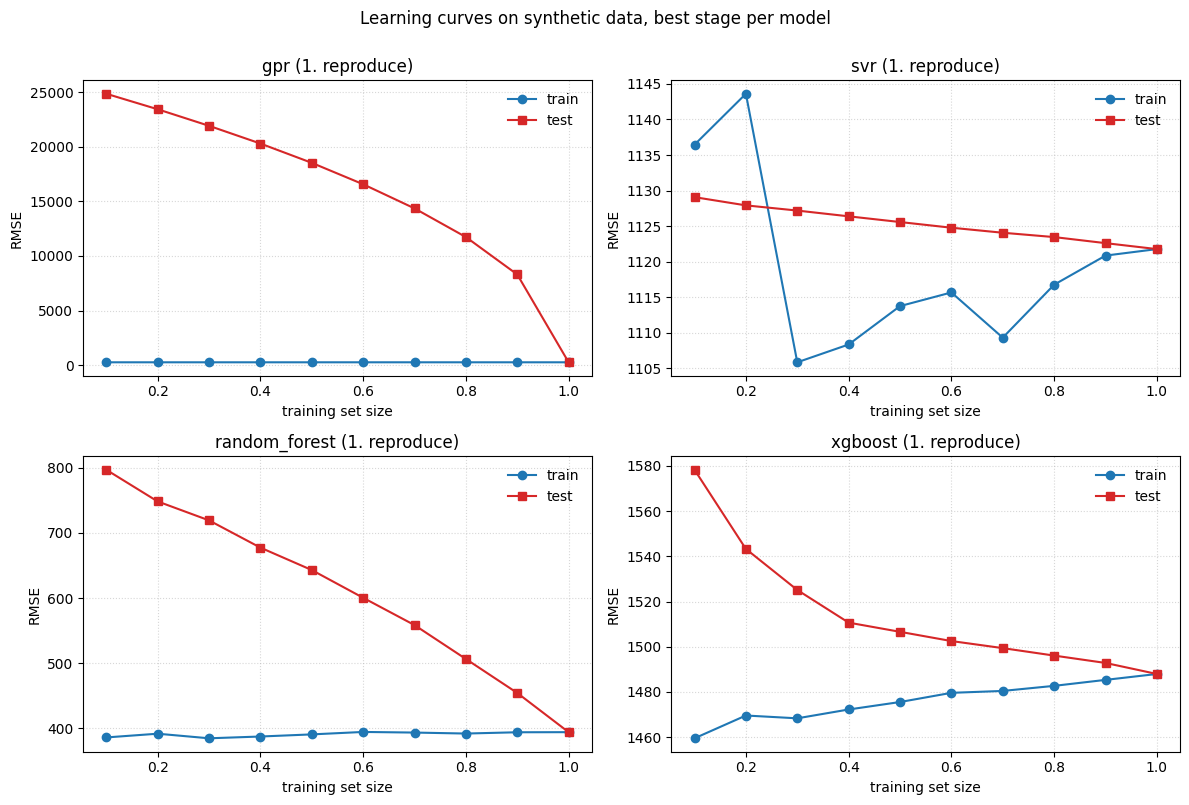

saved reports\figures\synth_learning_curves.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

best_stage_per_model = (
    results_synth.sort_values('r2', ascending=False)
    .groupby('model', sort=False)
    .first()
    .reset_index()
)

for ax, (_, row) in zip(axes, best_stage_per_model.iterrows()):
    model_name = row['model']
    stage_name = row['stage']
    est = fitted_synth[(model_name, stage_name)]

    X_raw = X_synth_orig  if row['layout'] == 'original' else X_synth_fixed
    y_raw = y_synth_orig  if row['layout'] == 'original' else y_synth_fixed

    viz.plot_learning_curve(
        train.clone_factory(est),
        X_raw, y_raw, X_raw, y_raw,
        title=f'{model_name} ({stage_name})',
        ax=ax,
    )

fig.suptitle('Learning curves on synthetic data, best stage per model', y=1.00)
fig.tight_layout()
p = viz.save_figure(fig, 'synth_learning_curves')
plt.show()
print('saved', p)

## 5. Prediction scatters per model

Predicted vs true on the synthetic test split, best stage per model.

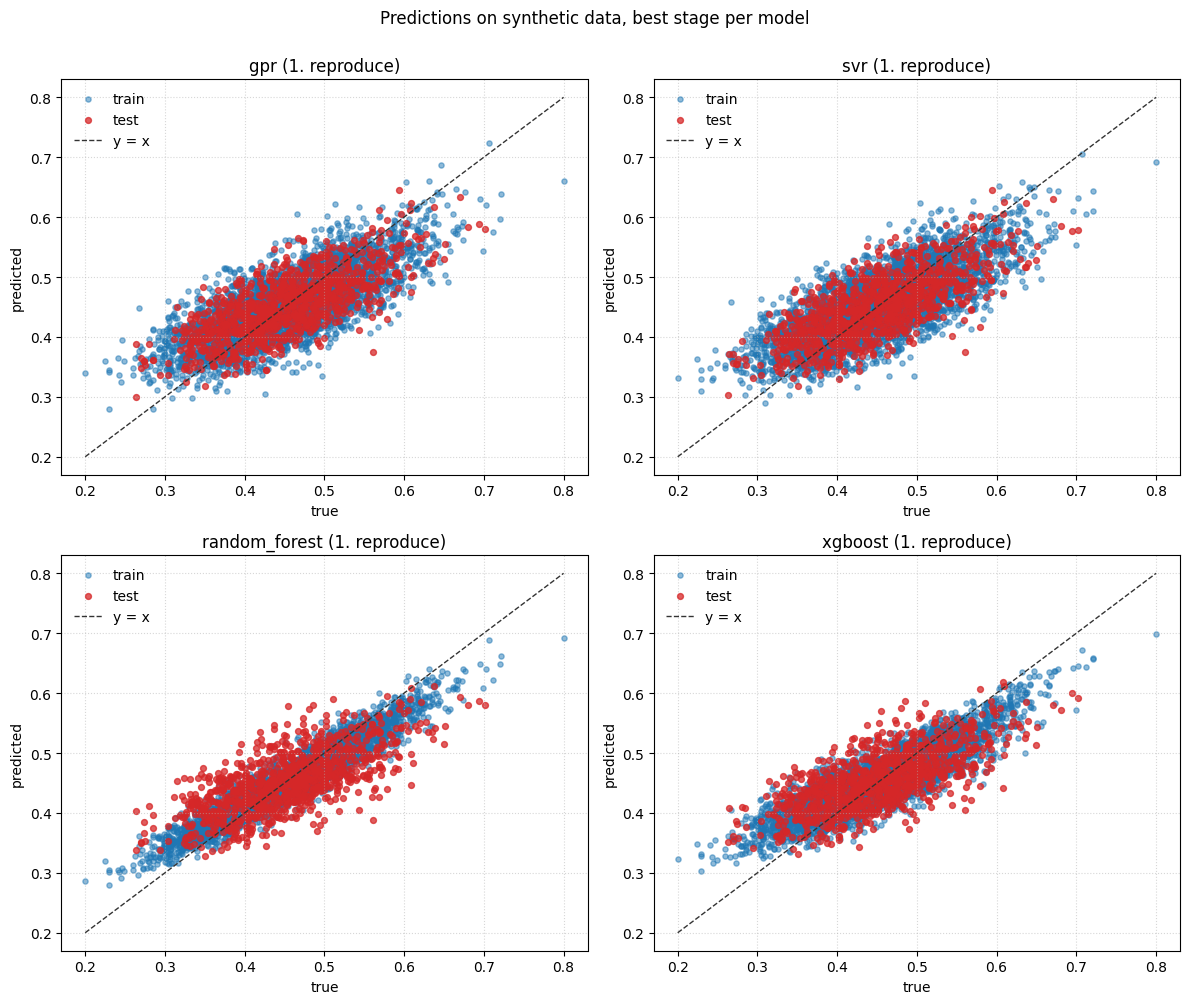

saved reports\figures\synth_predictions.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (_, row) in zip(axes, best_stage_per_model.iterrows()):
    model_name = row['model']
    stage_name = row['stage']
    est = fitted_synth[(model_name, stage_name)]

    X_raw = X_synth_orig  if row['layout'] == 'original' else X_synth_fixed
    y_raw = y_synth_orig  if row['layout'] == 'original' else y_synth_fixed

    train_idx, test_idx = train._split_indices(len(X_raw))
    if row['scale_strategy'] == 'original':
        X_tr, X_te, y_tr, y_te, _ = train._scale_original(
            X_raw, y_raw, train_idx, test_idx
        )
    else:
        X_tr, X_te, y_tr, y_te, _ = train._scale_principled(
            X_raw, y_raw, train_idx, test_idx
        )

    viz.plot_predictions(
        y_tr, est.predict(X_tr),
        y_te, est.predict(X_te),
        title=f'{model_name} ({stage_name})',
        ax=ax,
    )

fig.suptitle('Predictions on synthetic data, best stage per model', y=1.00)
fig.tight_layout()
p = viz.save_figure(fig, 'synth_predictions')
plt.show()
print('saved', p)

## 6. Takeaways

The synthetic track repeats the pattern from the real track: stage 1 (reproduce) is weak, stage 2 (layout fix) jumps sharply. That confirms the layout bug was not a real-data phenomenon. It affects any dataset that inherits the scrambled row pairing, including GAN output trained on that pairing.

The target-spread caveat from notebook 2 still applies. Scaled RMSE values here are not directly comparable to notebook 3 because the target variance differs by roughly 2.3x. The `test_rmse_hours` column corrects for this and is the honest physical comparison.

The cross-evaluation section in notebook 5 closes the loop: does a model trained on this synthetic data transfer to real data?

Next: `05_results_comparison.ipynb`, which concatenates the two partial CSVs, exports `results/metrics.csv`, draws the stage comparison bars, and runs the synthetic-to-real cross-evaluation.
